In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['message'] = df['message'].apply(clean_text)

In [5]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['message'])

In [6]:
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = MultinomialNB(alpha=1.0)  # Laplace smoothing
model.fit(X_train, y_train)

MultinomialNB()

In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9560538116591928
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       965
           1       1.00      0.67      0.80       150

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



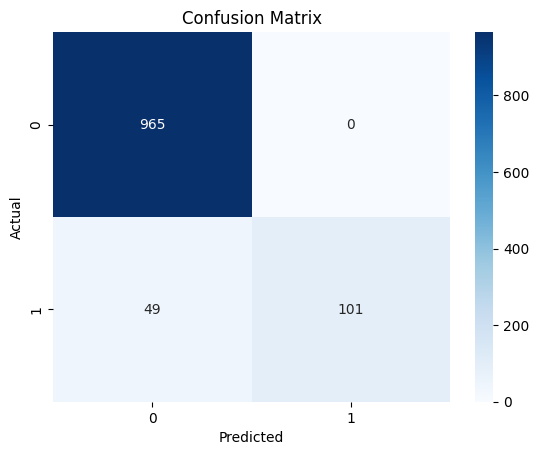

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
feature_names = vectorizer.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]

top_spam_words = np.argsort(spam_probs)[-10:]

for i in top_spam_words:
    print(feature_names[i])

mobile
for
txt
now
or
you
your
free
call
to


In [ ]:
model2 = MultinomialNB(alpha=0.1)
model2.fit(X_train, y_train)
print("Accuracy with alpha=0.1:", model2.score(X_test, y_test))